In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):j
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

IndentationError: unexpected indent (3666686732.py, line 13)

Device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ SELD model loaded successfully.
✓ Loaded 107 scenes from 500 Days of Summer
  GT distribution: Counter({'Negative_Distressing': 44, 'Neutral_Complex': 35, 'Positive_Uplifting': 27, 'Tension_Action': 1})

── SELD Direct Inference — 500 Days of Summer ──
Accuracy : 36/107 = 33.6%
Macro F1 : 0.2213

GT dist  : Counter({'Negative_Distressing': 44, 'Neutral_Complex': 35, 'Positive_Uplifting': 27, 'Tension_Action': 1})
Pred dist: Counter({'Neutral_Complex': 70, 'Positive_Uplifting': 28, 'Negative_Distressing': 5, 'Tension_Action': 4})

Classification Report:
                      precision    recall  f1-score   support

  Positive_Uplifting       0.32      0.33      0.33        27
     Neutral_Complex       0.36      0.71      0.48        35
      Tension_Action       0.00      0.00      0.00         1
Negative_Distressing       0.40      0.05      0.08        44

            accuracy                           0.34       107
           macro avg       0.27      0.27      0.22       107
   

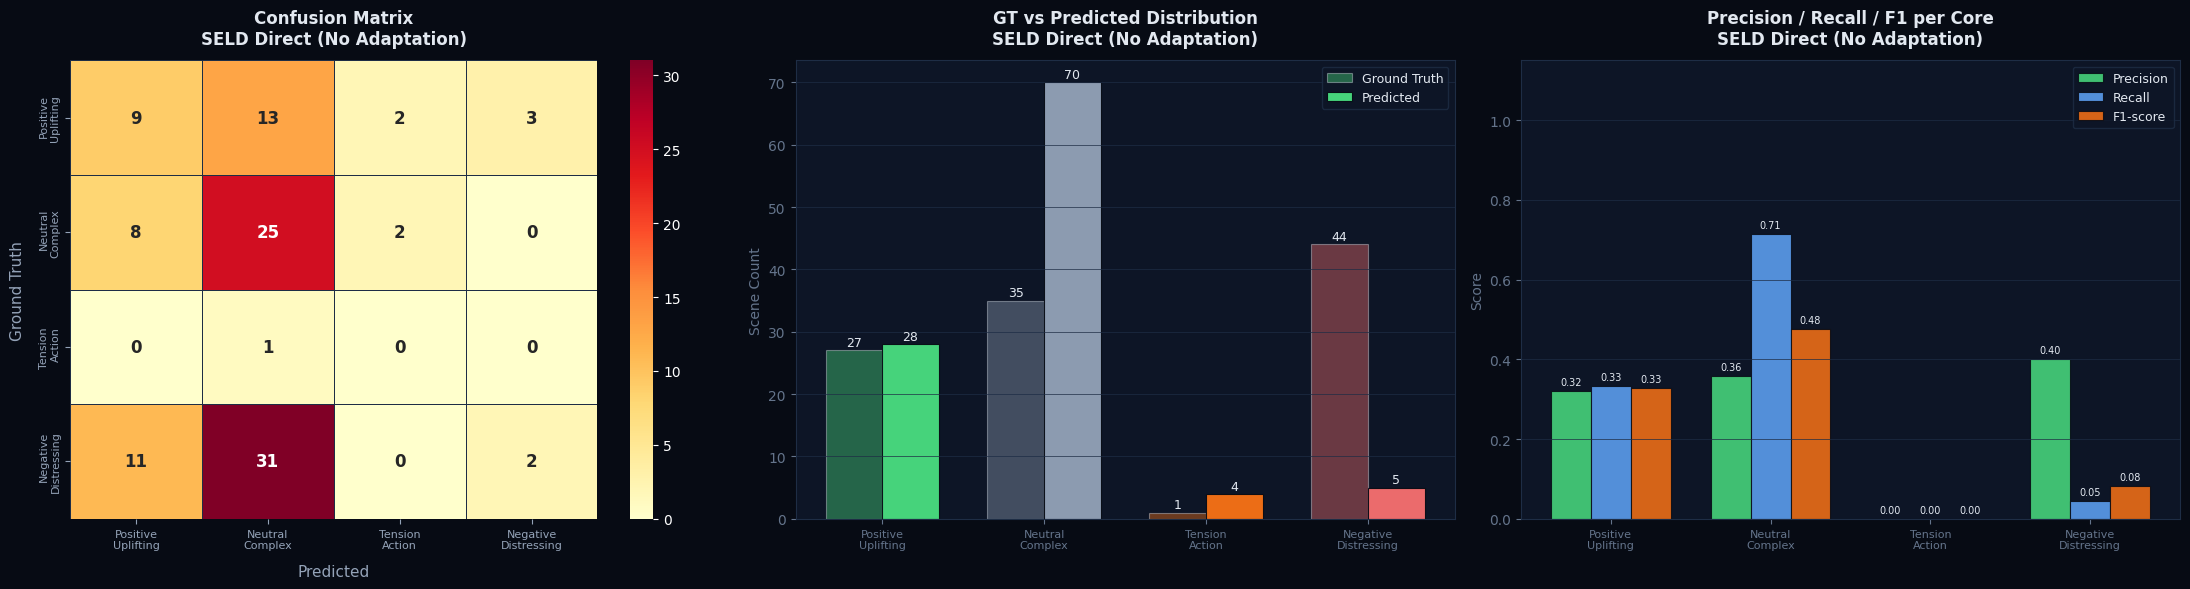

In [2]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════
import json, math, re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Config
# ═══════════════════════════════════════════════════════════════
MAX_LEN     = 128
BATCH_SIZE  = 32
EMBED_DIM   = 768
NUM_HEADS   = 8
FF_DIM      = 2048
DROPOUT     = 0.2
NUM_CLASSES = 9

# Must match exact order from training notebook
# Run: print([label_names[i] for i in valid_labels]) in training nb to verify
EMOTION_NAMES = ["neutral", "admiration", "approval", "gratitude",
                 "annoyance", "disapproval", "amusement", "curiosity", "love"]

EMOTION_TO_CORE = {
    "neutral"     : "Neutral_Complex",
    "admiration"  : "Positive_Uplifting",
    "approval"    : "Positive_Uplifting",
    "amusement"   : "Positive_Uplifting",
    "gratitude"   : "Positive_Uplifting",
    "love"        : "Positive_Uplifting",
    "curiosity"   : "Tension_Action",
    "annoyance"   : "Negative_Distressing",
    "disapproval" : "Negative_Distressing",
}

CORE_ORDER  = ["Positive_Uplifting", "Neutral_Complex",
               "Tension_Action",     "Negative_Distressing"]

CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

EXTENDED_CORE_MAP = {
    "Positive_Uplifting"   : "Positive_Uplifting",
    "Neutral_Complex"      : "Neutral_Complex",
    "Tension_Action"       : "Tension_Action",
    "Negative_Distressing" : "Negative_Distressing",
    "Awe_Wonder"           : "Positive_Uplifting",
    "Heroic_Triumph"       : "Positive_Uplifting",
    "Relief_Catharsis"     : "Positive_Uplifting",
    "Humor_Levity"         : "Positive_Uplifting",
    "Camaraderie_Bonding"  : "Positive_Uplifting",
    "Epic_Grandiose"       : "Tension_Action",
    "Anger_Defiance"       : "Tension_Action",
    "Suspense_Unease"      : "Tension_Action",
    "Determination"        : "Tension_Action",
    "Urgency_Desperation"  : "Tension_Action",
    "Dread_Fear"           : "Negative_Distressing",
    "Sacrifice"            : "Negative_Distressing",
    "Grief_Loss"           : "Negative_Distressing",
    "Shock_Disbelief"      : "Negative_Distressing",
    "Melancholy_Longing"   : "Negative_Distressing",
}

MODEL_PATH  = "/kaggle/input/models/harshalkarangale/cl-encoder/pytorch/default/1/best_model.pt"
SUMMER_PATH = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════
#  CELL 3 — Architecture (must match training exactly)
# ═══════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.head_dim  = embed_dim // num_heads
        self.num_heads = num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q       = nn.Linear(embed_dim, embed_dim)
        self.W_k       = nn.Linear(embed_dim, embed_dim)
        self.W_v       = nn.Linear(embed_dim, embed_dim)
        self.W_o       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, E = x.shape
        def split(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, E)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, heads=NUM_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(embed_dim, heads, dropout)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Tanh(), nn.Linear(256, 1)
        )
    def forward(self, x, mask=None):
        scores = self.scorer(x)
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, None] == 0, float("-inf"))
        return (torch.softmax(scores, dim=1) * x).sum(dim=1)


class EmotionTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.enc1       = TransformerEncoderLayer()
        self.enc2       = TransformerEncoderLayer()
        self.pool       = AttentionPooling()
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).last_hidden_state
        x = self.enc1(x, mask=attention_mask)
        x = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))


# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Load model
# ═══════════════════════════════════════════════════════════════
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = EmotionTransformer(num_classes=NUM_CLASSES, dropout=DROPOUT).to(device)
state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()
print("✓ SELD model loaded successfully.")

# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Load 500 Days of Summer JSON
# ═══════════════════════════════════════════════════════════════
def load_script_json(path):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)
    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])
    return data

raw_scenes = load_script_json(SUMMER_PATH)

texts        = []
gt_cores     = []
scene_ids    = []
scene_headers= []

for s in raw_scenes:
    text = str(s.get("scene_text", "")).strip()
    core = s.get("emotional_core")
    if not text or core is None:
        continue
    mapped = EXTENDED_CORE_MAP.get(core.strip())
    if mapped is None:
        continue
    texts.append(text)
    gt_cores.append(mapped)
    scene_ids.append(s.get("scene_id", ""))
    scene_headers.append(s.get("scene_header", ""))

print(f"✓ Loaded {len(texts)} scenes from 500 Days of Summer")
print(f"  GT distribution: {Counter(gt_cores)}")

# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Inference dataset
# ═══════════════════════════════════════════════════════════════
class SceneDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

loader = DataLoader(SceneDataset(texts), batch_size=BATCH_SIZE, shuffle=False)

# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Run inference
# ═══════════════════════════════════════════════════════════════
all_probs = []

with torch.no_grad():
    for input_ids, mask in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        logits    = model(input_ids, mask)
        probs     = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)

probs = np.vstack(all_probs)   # (N, 9)

# Map probabilities → cinematic core via max-pooling per core group
def probs_to_core(prob_row):
    core_scores = {c: 0.0 for c in CORE_ORDER}
    for j, ename in enumerate(EMOTION_NAMES):
        core = EMOTION_TO_CORE[ename]
        core_scores[core] = max(core_scores[core], float(prob_row[j]))
    return max(core_scores, key=core_scores.get)

pred_cores = [probs_to_core(p) for p in probs]

# ═══════════════════════════════════════════════════════════════
#  CELL 8 — Metrics
# ═══════════════════════════════════════════════════════════════
correct = sum(p == g for p, g in zip(pred_cores, gt_cores))
print(f"\n── SELD Direct Inference — 500 Days of Summer ──")
print(f"Accuracy : {correct}/{len(pred_cores)} = {correct/len(pred_cores)*100:.1f}%")
print(f"Macro F1 : {f1_score(gt_cores, pred_cores, labels=CORE_ORDER, average='macro', zero_division=0):.4f}")
print(f"\nGT dist  : {Counter(gt_cores)}")
print(f"Pred dist: {Counter(pred_cores)}")
print(f"\nClassification Report:")
print(classification_report(gt_cores, pred_cores, labels=CORE_ORDER, zero_division=0))

# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Plots
# ═══════════════════════════════════════════════════════════════
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor("#070b14")

# ── Plot 1: Confusion Matrix ──
cm = confusion_matrix(gt_cores, pred_cores, labels=CORE_ORDER)
ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix\nSELD Direct (No Adaptation)",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── Plot 2: GT vs Predicted Distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(gt_cores)
pred_dist = Counter(pred_cores)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]
b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count", color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution\nSELD Direct (No Adaptation)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

# ── Plot 3: Per-class Precision / Recall / F1 ──
ax3 = axes[2]
ax3.set_facecolor("#0d1526")
report_dict   = classification_report(
    gt_cores, pred_cores, labels=CORE_ORDER,
    zero_division=0, output_dict=True
)
metrics       = ["precision", "recall", "f1-score"]
metric_colors = ["#4ade80",   "#60a5fa", "#f97316"]
x             = np.arange(len(CORE_ORDER))
bw            = 0.25
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report_dict[c][metric] for c in CORE_ORDER]
    bars = ax3.bar(x + i * bw, vals, bw, label=metric.capitalize(),
                   color=color, alpha=0.85, edgecolor="#070b14", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom",
                 fontsize=7, color="#e2e8f0")
ax3.set_xticks(x + bw)
ax3.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score", color="#64748b", fontsize=10)
ax3.set_title("Precision / Recall / F1 per Core\nSELD Direct (No Adaptation)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax3.tick_params(colors="#64748b")
ax3.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax3.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax3.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/seld_direct_inference.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

With freezing

Device: cpu


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ SELD model loaded successfully.
✓ Loaded 107 scenes from 500 Days of Summer
  GT distribution: Counter({'Negative_Distressing': 44, 'Neutral_Complex': 35, 'Positive_Uplifting': 27, 'Tension_Action': 1})

── SELD Direct Inference — 500 Days of Summer ──
Accuracy : 28/107 = 26.2%
Macro F1 : 0.1796

GT dist  : Counter({'Negative_Distressing': 44, 'Neutral_Complex': 35, 'Positive_Uplifting': 27, 'Tension_Action': 1})
Pred dist: Counter({'Neutral_Complex': 62, 'Positive_Uplifting': 34, 'Negative_Distressing': 7, 'Tension_Action': 4})

Classification Report:
                      precision    recall  f1-score   support

  Positive_Uplifting       0.21      0.26      0.23        27
     Neutral_Complex       0.29      0.51      0.37        35
      Tension_Action       0.00      0.00      0.00         1
Negative_Distressing       0.43      0.07      0.12        44

            accuracy                           0.26       107
           macro avg       0.23      0.21      0.18       107
   

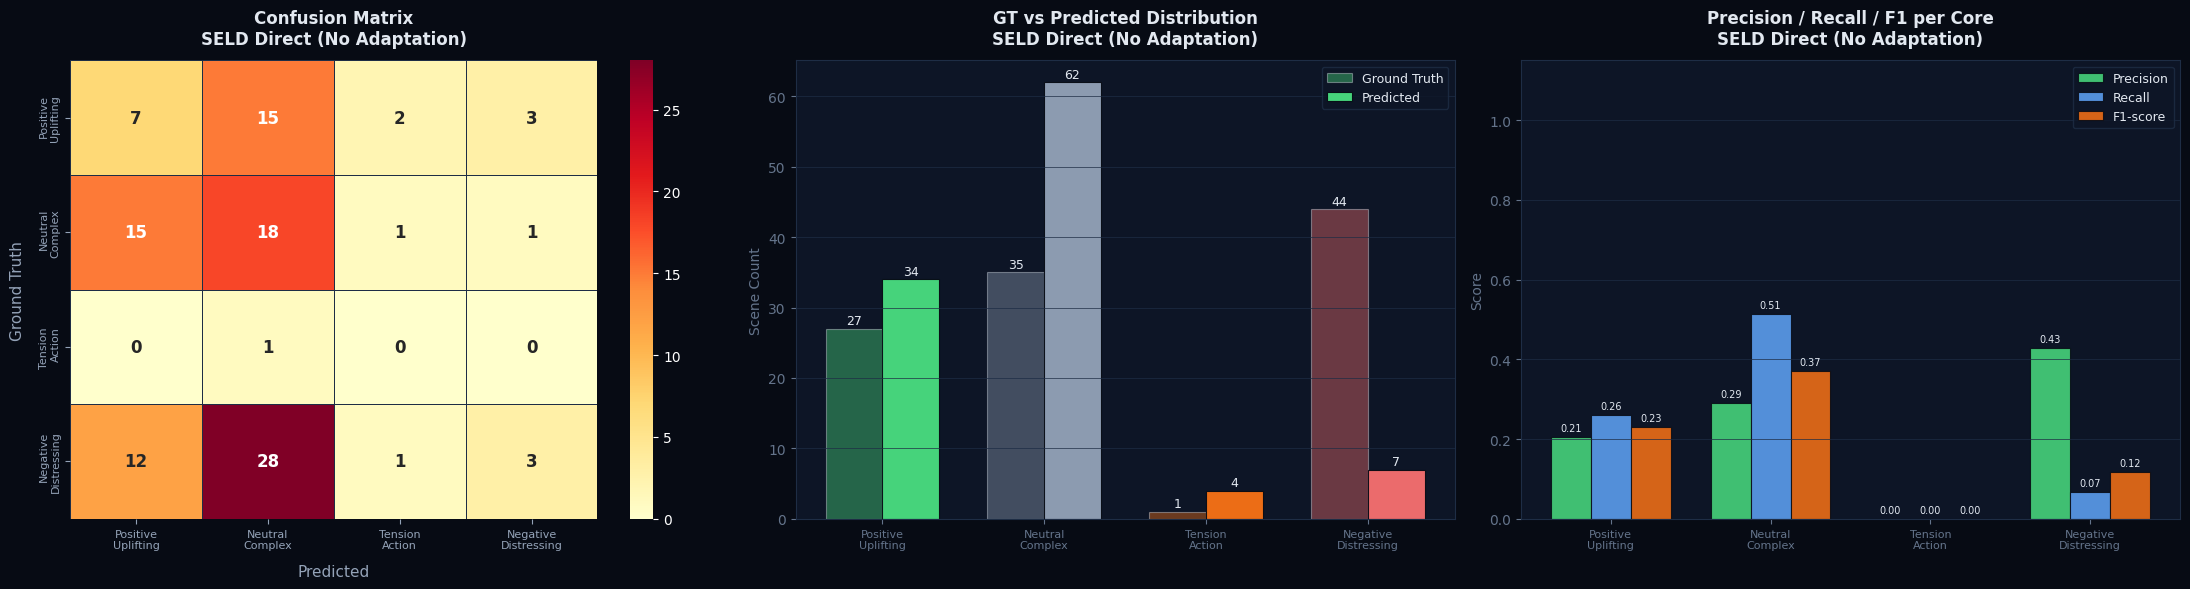

In [2]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════
import json, math, re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from collections import Counter
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Config
# ═══════════════════════════════════════════════════════════════
MAX_LEN     = 128
BATCH_SIZE  = 32
EMBED_DIM   = 768
NUM_HEADS   = 8
FF_DIM      = 2048
DROPOUT     = 0.2
NUM_CLASSES = 9

# Must match exact order from training notebook
# Run: print([label_names[i] for i in valid_labels]) in training nb to verify
EMOTION_NAMES = ["neutral", "admiration", "approval", "gratitude",
                 "annoyance", "disapproval", "amusement", "curiosity", "love"]

EMOTION_TO_CORE = {
    "neutral"     : "Neutral_Complex",
    "admiration"  : "Positive_Uplifting",
    "approval"    : "Positive_Uplifting",
    "amusement"   : "Positive_Uplifting",
    "gratitude"   : "Positive_Uplifting",
    "love"        : "Positive_Uplifting",
    "curiosity"   : "Tension_Action",
    "annoyance"   : "Negative_Distressing",
    "disapproval" : "Negative_Distressing",
}

CORE_ORDER  = ["Positive_Uplifting", "Neutral_Complex",
               "Tension_Action",     "Negative_Distressing"]

CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

EXTENDED_CORE_MAP = {
    "Positive_Uplifting"   : "Positive_Uplifting",
    "Neutral_Complex"      : "Neutral_Complex",
    "Tension_Action"       : "Tension_Action",
    "Negative_Distressing" : "Negative_Distressing",
    "Awe_Wonder"           : "Positive_Uplifting",
    "Heroic_Triumph"       : "Positive_Uplifting",
    "Relief_Catharsis"     : "Positive_Uplifting",
    "Humor_Levity"         : "Positive_Uplifting",
    "Camaraderie_Bonding"  : "Positive_Uplifting",
    "Epic_Grandiose"       : "Tension_Action",
    "Anger_Defiance"       : "Tension_Action",
    "Suspense_Unease"      : "Tension_Action",
    "Determination"        : "Tension_Action",
    "Urgency_Desperation"  : "Tension_Action",
    "Dread_Fear"           : "Negative_Distressing",
    "Sacrifice"            : "Negative_Distressing",
    "Grief_Loss"           : "Negative_Distressing",
    "Shock_Disbelief"      : "Negative_Distressing",
    "Melancholy_Longing"   : "Negative_Distressing",
}

MODEL_PATH  = "/kaggle/input/models/harshalkarangale/cl-encoder-freeze/pytorch/default/1/best_model_freeze.pt"
SUMMER_PATH = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════
#  CELL 3 — Architecture (must match training exactly)
# ═══════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.head_dim  = embed_dim // num_heads
        self.num_heads = num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q       = nn.Linear(embed_dim, embed_dim)
        self.W_k       = nn.Linear(embed_dim, embed_dim)
        self.W_v       = nn.Linear(embed_dim, embed_dim)
        self.W_o       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, E = x.shape
        def split(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, E)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, heads=NUM_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(embed_dim, heads, dropout)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Tanh(), nn.Linear(256, 1)
        )
    def forward(self, x, mask=None):
        scores = self.scorer(x)
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, None] == 0, float("-inf"))
        return (torch.softmax(scores, dim=1) * x).sum(dim=1)


class EmotionTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.enc1       = TransformerEncoderLayer()
        self.enc2       = TransformerEncoderLayer()
        self.pool       = AttentionPooling()
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).last_hidden_state
        x = self.enc1(x, mask=attention_mask)
        x = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))


# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Load model
# ═══════════════════════════════════════════════════════════════
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = EmotionTransformer(num_classes=NUM_CLASSES, dropout=DROPOUT).to(device)
state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()
print("✓ SELD model loaded successfully.")

# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Load 500 Days of Summer JSON
# ═══════════════════════════════════════════════════════════════
def load_script_json(path):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)
    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])
    return data

raw_scenes = load_script_json(SUMMER_PATH)

texts        = []
gt_cores     = []
scene_ids    = []
scene_headers= []

for s in raw_scenes:
    text = str(s.get("scene_text", "")).strip()
    core = s.get("emotional_core")
    if not text or core is None:
        continue
    mapped = EXTENDED_CORE_MAP.get(core.strip())
    if mapped is None:
        continue
    texts.append(text)
    gt_cores.append(mapped)
    scene_ids.append(s.get("scene_id", ""))
    scene_headers.append(s.get("scene_header", ""))

print(f"✓ Loaded {len(texts)} scenes from 500 Days of Summer")
print(f"  GT distribution: {Counter(gt_cores)}")

# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Inference dataset
# ═══════════════════════════════════════════════════════════════
class SceneDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

loader = DataLoader(SceneDataset(texts), batch_size=BATCH_SIZE, shuffle=False)

# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Run inference
# ═══════════════════════════════════════════════════════════════
all_probs = []

with torch.no_grad():
    for input_ids, mask in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        logits    = model(input_ids, mask)
        probs     = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)

probs = np.vstack(all_probs)   # (N, 9)

# Map probabilities → cinematic core via max-pooling per core group
def probs_to_core(prob_row):
    core_scores = {c: 0.0 for c in CORE_ORDER}
    for j, ename in enumerate(EMOTION_NAMES):
        core = EMOTION_TO_CORE[ename]
        core_scores[core] = max(core_scores[core], float(prob_row[j]))
    return max(core_scores, key=core_scores.get)

pred_cores = [probs_to_core(p) for p in probs]

# ═══════════════════════════════════════════════════════════════
#  CELL 8 — Metrics
# ═══════════════════════════════════════════════════════════════
correct = sum(p == g for p, g in zip(pred_cores, gt_cores))
print(f"\n── SELD Direct Inference — 500 Days of Summer ──")
print(f"Accuracy : {correct}/{len(pred_cores)} = {correct/len(pred_cores)*100:.1f}%")
print(f"Macro F1 : {f1_score(gt_cores, pred_cores, labels=CORE_ORDER, average='macro', zero_division=0):.4f}")
print(f"\nGT dist  : {Counter(gt_cores)}")
print(f"Pred dist: {Counter(pred_cores)}")
print(f"\nClassification Report:")
print(classification_report(gt_cores, pred_cores, labels=CORE_ORDER, zero_division=0))

# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Plots
# ═══════════════════════════════════════════════════════════════
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor("#070b14")

# ── Plot 1: Confusion Matrix ──
cm = confusion_matrix(gt_cores, pred_cores, labels=CORE_ORDER)
ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix\nSELD Direct (No Adaptation)",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── Plot 2: GT vs Predicted Distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(gt_cores)
pred_dist = Counter(pred_cores)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]
b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count", color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution\nSELD Direct (No Adaptation)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

# ── Plot 3: Per-class Precision / Recall / F1 ──
ax3 = axes[2]
ax3.set_facecolor("#0d1526")
report_dict   = classification_report(
    gt_cores, pred_cores, labels=CORE_ORDER,
    zero_division=0, output_dict=True
)
metrics       = ["precision", "recall", "f1-score"]
metric_colors = ["#4ade80",   "#60a5fa", "#f97316"]
x             = np.arange(len(CORE_ORDER))
bw            = 0.25
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report_dict[c][metric] for c in CORE_ORDER]
    bars = ax3.bar(x + i * bw, vals, bw, label=metric.capitalize(),
                   color=color, alpha=0.85, edgecolor="#070b14", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom",
                 fontsize=7, color="#e2e8f0")
ax3.set_xticks(x + bw)
ax3.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score", color="#64748b", fontsize=10)
ax3.set_title("Precision / Recall / F1 per Core\nSELD Direct (No Adaptation)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax3.tick_params(colors="#64748b")
ax3.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax3.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax3.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/seld_direct_inference.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.rshow()